In [9]:
"""
generate_data.jl

Compute CMI data for three geometries and save to cmi_data.jld2.

Geometry definitions  (B sweeps 0:ABC-A in all cases)
──────────────────────────────────────────────────────
  :full   N = ABC,     C = ABC-A-B  (shrinks),  no D
          I = S_AB + S_BC - S_B - S_N

  :corr   N = 2·ABC,   C = 1  (fixed, single-site probe)
          D = N-A-B-1  (shrinks as B grows)
          I = S_AB + S_BC - S_B - S_ABC

  :third  N = 2·ABC,   C = ABC-A-B  (large, shrinks)
          D = ABC  (fixed throughout)
          I = S_AB + S_BC - S_B - S_ABC

Parameters
──────────
  A       ∈ {5, 10, 20}
  ABC     ∈ {100, 200, 400}
  filling ∈ {0.5, 0.75},  k = round(filling · N)

Data structure
──────────────
  data[(geom, A, ABC, filling)] =
      (bs       = Vector{Int},      # B values
       cmis     = Vector{Float64},  # CMI in nats
       ana_cmis = Vector{Float64})  # analytic prediction in nats

Reload with:
    # using JLD2
    # data = load("cmi_data.jld2", "data")
"""

using JLD2

# ─────────────────────────────────────────────────────────────
# Core: entropy of M sites in the fixed-point U(1) SW-SSB state
# ─────────────────────────────────────────────────────────────

"""
    S(n, m, k) -> Float64

Von Neumann entropy S(ρ_M) of a region of m sites, in a system
of n sites with k charges.  Uses BigInt to avoid overflow.

Each bitstring on M sites with X charges has eigenvalue
    λ = C(n-m, k-x) / C(n, k)
with degeneracy C(m, x), giving  S = -∑_x C(m,x) λ log λ.
"""
function S(n::Integer, m::Integer, k::Integer)::Float64
    m == 0 && return 0.0
    m == n && return log(Float64(binomial(BigInt(n), BigInt(k))))
    (k == 0 || k == n) && return 0.0

    x_lo = max(0, k - (n - m))
    x_hi = min(m, k)
    bn   = binomial(BigInt(n), BigInt(k))

    total = 0.0
    for x in x_lo:x_hi
        bnm = binomial(BigInt(n - m), BigInt(k - x))
        bm  = binomial(BigInt(m),     BigInt(x))
        iszero(bnm) && continue
        λ   = Float64(bnm / bn)
        p_x = Float64(bm * bnm / bn)
        total -= p_x * log(λ)
    end
    return total
end

# ─────────────────────────────────────────────────────────────
# CMI:  I(A:C|B) = S_AB + S_BC - S_B - S_ref
#   :full  -> S_ref = S_N   (full system)
#   :corr,
#   :third -> S_ref = S_ABC (traced-out D)
# ─────────────────────────────────────────────────────────────

function cmi(n::Int, a::Int, b::Int, c::Int, k::Int, geom::Symbol)::Float64
    (a < 0 || b < 0 || c < 0) && return NaN
    s_ref = geom == :full ? S(n, n, k) : S(n, a + b + c, k)
    return S(n, a + b, k) + S(n, b + c, k) - S(n, b, k) - s_ref
end

# ─────────────────────────────────────────────────────────────
# Analytical predictions  (nats)
# ─────────────────────────────────────────────────────────────

# Full-system: valid when A, C ~ O(N)
analytic_full(a, c, kfrac) =
    (a > 0 && c > 0) ?
        0.5 * log(2pi * exp(1) * kfrac * (1 - kfrac) * a * c / (a + c)) : NaN

# Correlator/third: valid when A, C, D ~ O(N); independent of filling
analytic_corr(a, c, d) =
    (a > 0 && c > 0 && d > 0) ?
        0.5 * log((a + d) * (c + d) / (d * (a + c + d))) : NaN

# ─────────────────────────────────────────────────────────────
# Parameter grid
# ─────────────────────────────────────────────────────────────

const A_VALUES   = [5, 10, 20]
const ABC_VALUES = [100, 200, 400]
const FILLINGS   = [0.5, 0.75]
const GEOMETRIES = [:full, :corr, :third]

# ─────────────────────────────────────────────────────────────
# Data generation
# ─────────────────────────────────────────────────────────────

function generate_data()::Dict
    data  = Dict()
    total = length(GEOMETRIES) * length(A_VALUES) * length(ABC_VALUES) * length(FILLINGS)
    done  = 0

    for geom in GEOMETRIES, A in A_VALUES, ABC in ABC_VALUES, filling in FILLINGS

        # System size and charge
        n = (geom == :full) ? ABC : 2 * ABC
        k = round(Int, filling * n)

        # B sweeps 0:ABC-A in all geometries.
        # :corr  -> C = 1 (fixed), D = n-A-B-1 (shrinks with B)
        # :full  -> C = ABC-A-B (shrinks), no D
        # :third -> C = ABC-A-B (shrinks), D = ABC (fixed)
        bs = collect(0:(ABC - A))

        cmis     = Vector{Float64}(undef, length(bs))
        ana_cmis = Vector{Float64}(undef, length(bs))

        for (i, b) in enumerate(bs)
            if geom == :corr
                c = 1
                d = n - A - b - c          # shrinks as B grows
            else
                c = ABC - A - b            # shrinks as B grows
                d = (geom == :third) ? ABC : 0
            end

            cmis[i] = cmi(n, A, b, c, k, geom)

            ana_cmis[i] = if geom == :full
                analytic_full(A, c, filling)
            else
                analytic_corr(A, c, d)
            end
        end

        key = (geom, A, ABC, filling)
        data[key] = (bs = bs, cmis = cmis, ana_cmis = ana_cmis)

        done += 1
        n_str = (geom == :full) ? "N=ABC=$ABC" : "N=2*ABC=$(2*ABC)"
        println("[$done/$total]  geom=$geom  A=$A  ABC=$ABC  filling=$filling  $n_str  k=$k")
    end

    return data
end

# ─────────────────────────────────────────────────────────────
# Run and save
# ─────────────────────────────────────────────────────────────

println("Generating CMI data...")
data = generate_data()

jldsave("cmi_data.jld2"; data)
println("\nSaved to cmi_data.jld2")
println("Reload with:")
println("    using JLD2")
println("    data = load(\"cmi_data.jld2\", \"data\")")
println("\nKeys: (geom::Symbol, A::Int, ABC::Int, filling::Float64)")
println("Values: NamedTuple (bs, cmis, ana_cmis) — CMI values in nats; / log(2) for bits")


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


Generating CMI data...
[1/54]  geom=full  A=5  ABC=100  filling=0.5  N=ABC=100  k=50
[2/54]  geom=full  A=5  ABC=100  filling=0.75  N=ABC=100  k=75
[3/54]  geom=full  A=5  ABC=200  filling=0.5  N=ABC=200  k=100
[4/54]  geom=full  A=5  ABC=200  filling=0.75  N=ABC=200  k=150
[5/54]  geom=full  A=5  ABC=400  filling=0.5  N=ABC=400  k=200
[6/54]  geom=full  A=5  ABC=400  filling=0.75  N=ABC=400  k=300
[7/54]  geom=full  A=10  ABC=100  filling=0.5  N=ABC=100  k=50
[8/54]  geom=full  A=10  ABC=100  filling=0.75  N=ABC=100  k=75
[9/54]  geom=full  A=10  ABC=200  filling=0.5  N=ABC=200  k=100
[10/54]  geom=full  A=10  ABC=200  filling=0.75  N=ABC=200  k=150
[11/54]  geom=full  A=10  ABC=400  filling=0.5  N=ABC=400  k=200
[12/54]  geom=full  A=10  ABC=400  filling=0.75  N=ABC=400  k=300
[13/54]  geom=full  A=20  ABC=100  filling=0.5  N=ABC=100  k=50
[14/54]  geom=full  A=20  ABC=100  filling=0.75  N=ABC=100  k=75
[15/54]  geom=full  A=20  ABC=200  filling=0.5  N=ABC=200  k=100
[16/54]  geom=fu

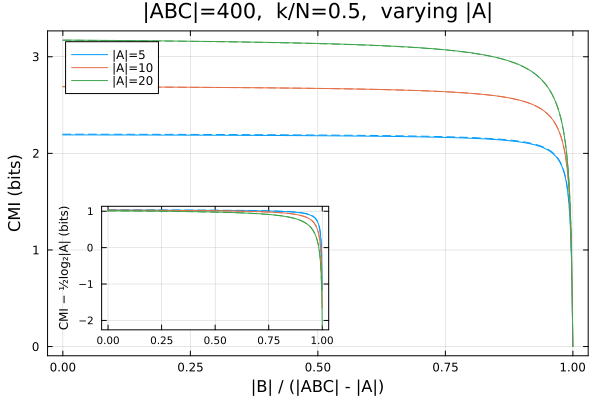

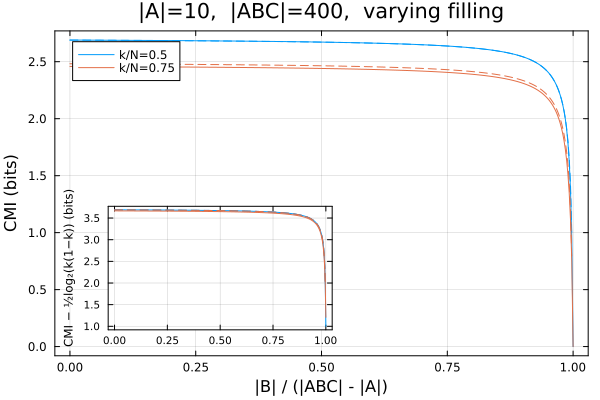

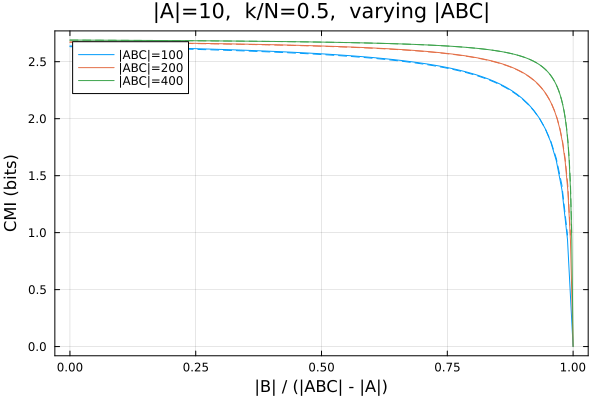

In [19]:
using Plots
using JLD2

data = load("cmi_data.jld2", "data")

const LN2 = log(2)

# ─────────────────────────────────────────────────────────────
# P6: ABC=400, filling=0.5, curves by |A|
#     inset: shift each curve by ½log₂|A| to collapse
# ─────────────────────────────────────────────────────────────

let geom = :full, ABC = 400, filling = 0.5, A_vals = [5, 10, 20]

    plt = plot()

    for (i, A) in enumerate(A_vals)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d  = data[key]
        xs = d.bs ./ (ABC - A)
        plot!(plt, xs, d.cmis ./ LN2; label = "|A|=$A", color = i)
        plot!(plt, xs, d.ana_cmis ./ LN2; color = i, linestyle = :dash, label = "")
    end
    plot!(plt;
        xlabel = "|B| / (|ABC| - |A|)",
        ylabel = "CMI (bits)",
        title  = "|ABC|=$ABC,  k/N=$filling,  varying |A|",
        legend = :topleft, frame = :box,
    )

    BB = bbox(0.1, 0.08, 0.42, 0.38, :bottom, :left)
    plot!(plt; inset=(1, BB), subplot=2, frame=:box, legend=false,
        ylabel="CMI − ½log₂|A| (bits)", tickfontsize=7, guidefontsize=8)
    for (i, A) in enumerate(A_vals)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d    = data[key]
        xs   = d.bs ./ (ABC - A)
        ys   = (d.cmis ./ LN2)     .- log2(A)/2
        ys_a = (d.ana_cmis ./ LN2) .- log2(A)/2
        plot!(plt, xs, ys;   subplot=2, color=i, label=false)
        plot!(plt, xs, ys_a; subplot=2, color=i, linestyle=:dash, label=false)
    end

    savefig(plt, "p6_vary_A.png")
    display(plt)
end

# ─────────────────────────────────────────────────────────────
# P7: A=10, ABC=400, curves by filling
#     inset: shift each curve by ½log₂(k(1-k)) to collapse
# ─────────────────────────────────────────────────────────────

let geom = :full, ABC = 400, A = 10, fillings = [0.5, 0.75]

    plt = plot()

    for (i, filling) in enumerate(fillings)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d  = data[key]
        xs = d.bs ./ (ABC - A)
        plot!(plt, xs, d.cmis ./ LN2; label = "k/N=$filling", color = i)
        plot!(plt, xs, d.ana_cmis ./ LN2; color = i, linestyle = :dash, label = "")
    end
    plot!(plt;
        xlabel = "|B| / (|ABC| - |A|)",
        ylabel = "CMI (bits)",
        title  = "|A|=$A,  |ABC|=$ABC,  varying filling",
        legend = :topleft, frame = :box,
    )

    BB = bbox(0.1, 0.08, 0.42, 0.38, :bottom, :left)
    plot!(plt; inset=(1, BB), subplot=2, frame=:box, legend=false,
        ylabel="CMI − ½log₂(k(1−k)) (bits)", tickfontsize=7, guidefontsize=8)
    for (i, filling) in enumerate(fillings)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d    = data[key]
        xs   = d.bs ./ (ABC - A)
        shift = log2(filling * (1 - filling)) / 2
        ys   = (d.cmis ./ LN2)     .- shift
        ys_a = (d.ana_cmis ./ LN2) .- shift
        plot!(plt, xs, ys;   subplot=2, color=i, label=false)
        plot!(plt, xs, ys_a; subplot=2, color=i, linestyle=:dash, label=false)
    end

    savefig(plt, "p7_vary_filling.png")
    display(plt)
end

# ─────────────────────────────────────────────────────────────
# P8: A=10, filling=0.5, curves by |ABC|
#     no inset
# ─────────────────────────────────────────────────────────────

let geom = :full, A = 10, filling = 0.5, ABC_vals = [100, 200, 400]

    plt = plot()

    for (i, ABC) in enumerate(ABC_vals)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d  = data[key]
        xs = d.bs ./ (ABC - A)
        plot!(plt, xs, d.cmis ./ LN2; label = "|ABC|=$ABC", color = i)
        plot!(plt, xs, d.ana_cmis ./ LN2; color = i, linestyle = :dash, label = "")
    end
    plot!(plt;
        xlabel = "|B| / (|ABC| - |A|)",
        ylabel = "CMI (bits)",
        title  = "|A|=$A,  k/N=$filling,  varying |ABC|",
        legend = :topleft, frame = :box,
    )

    savefig(plt, "p8_vary_ABC.png")
    display(plt)
end

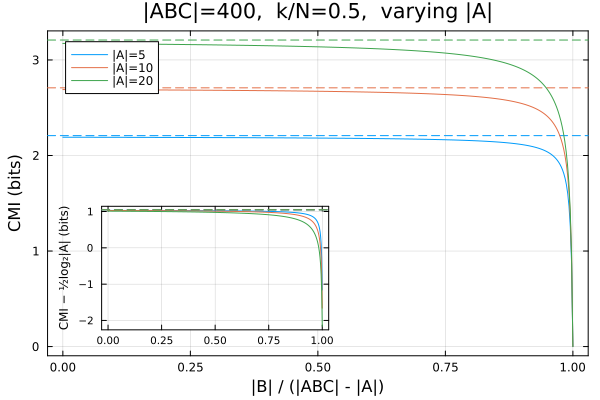

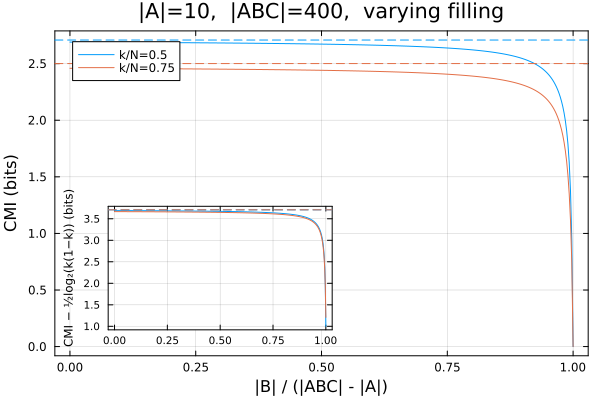

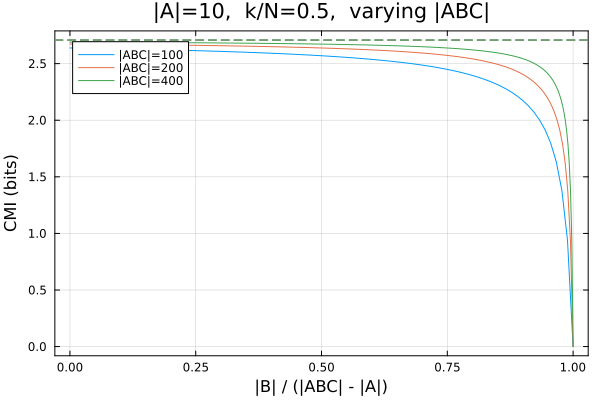

In [21]:
using Plots
using JLD2

data = load("cmi_data.jld2", "data")

const LN2 = log(2)

# fit: ½log₂(2πe |A| ν(1-ν)),  horizontal in B
fit_val(A, filling) = 0.5 * log2(2π * exp(1) * A * filling * (1 - filling))

# ─────────────────────────────────────────────────────────────
# P6: ABC=400, filling=0.5, curves by |A|
#     inset: shift each curve by ½log₂|A| to collapse
# ─────────────────────────────────────────────────────────────

let geom = :full, ABC = 400, filling = 0.5, A_vals = [5, 10, 20]

    plt = plot()

    for (i, A) in enumerate(A_vals)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d  = data[key]
        xs = d.bs ./ (ABC - A)
        plot!(plt, xs, d.cmis ./ LN2; label = "|A|=$A", color = i)
        hline!(plt, [fit_val(A, filling)]; color = i, linestyle = :dash, label = "")
    end
    plot!(plt;
        xlabel = "|B| / (|ABC| - |A|)",
        ylabel = "CMI (bits)",
        title  = "|ABC|=$ABC,  k/N=$filling,  varying |A|",
        legend = :topleft, frame = :box,
    )

    BB = bbox(0.1, 0.08, 0.42, 0.38, :bottom, :left)
    plot!(plt; inset=(1, BB), subplot=2, frame=:box, legend=false,
        ylabel="CMI − ½log₂|A| (bits)", tickfontsize=7, guidefontsize=8)
    for (i, A) in enumerate(A_vals)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d    = data[key]
        xs   = d.bs ./ (ABC - A)
        ys   = (d.cmis ./ LN2) .- log2(A)/2
        # shifted fit: ½log₂(2πe|A|ν(1-ν)) - ½log₂|A| = ½log₂(2πe ν(1-ν))
        fit_shifted = fit_val(A, filling) - log2(A)/2
        plot!(plt, xs, ys; subplot=2, color=i, label=false)
        hline!(plt, [fit_shifted]; subplot=2, color=i, linestyle=:dash, label=false)
    end

    savefig(plt, "p6_vary_A.png")
    display(plt)
end

# ─────────────────────────────────────────────────────────────
# P7: A=10, ABC=400, curves by filling
#     inset: shift each curve by ½log₂(k(1-k)) to collapse
# ─────────────────────────────────────────────────────────────

let geom = :full, ABC = 400, A = 10, fillings = [0.5, 0.75]

    plt = plot()

    for (i, filling) in enumerate(fillings)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d  = data[key]
        xs = d.bs ./ (ABC - A)
        plot!(plt, xs, d.cmis ./ LN2; label = "k/N=$filling", color = i)
        hline!(plt, [fit_val(A, filling)]; color = i, linestyle = :dash, label = "")
    end
    plot!(plt;
        xlabel = "|B| / (|ABC| - |A|)",
        ylabel = "CMI (bits)",
        title  = "|A|=$A,  |ABC|=$ABC,  varying filling",
        legend = :topleft, frame = :box,
    )

    BB = bbox(0.1, 0.08, 0.42, 0.38, :bottom, :left)
    plot!(plt; inset=(1, BB), subplot=2, frame=:box, legend=false,
        ylabel="CMI − ½log₂(k(1−k)) (bits)", tickfontsize=7, guidefontsize=8)
    for (i, filling) in enumerate(fillings)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d      = data[key]
        xs     = d.bs ./ (ABC - A)
        shift  = log2(filling * (1 - filling)) / 2
        ys     = (d.cmis ./ LN2) .- shift
        # shifted fit: ½log₂(2πe|A|ν(1-ν)) - ½log₂(ν(1-ν)) = ½log₂(2πe|A|)
        fit_shifted = fit_val(A, filling) - shift
        plot!(plt, xs, ys; subplot=2, color=i, label=false)
        hline!(plt, [fit_shifted]; subplot=2, color=i, linestyle=:dash, label=false)
    end

    savefig(plt, "p7_vary_filling.png")
    display(plt)
end

# ─────────────────────────────────────────────────────────────
# P8: A=10, filling=0.5, curves by |ABC|
#     no inset
# ─────────────────────────────────────────────────────────────

let geom = :full, A = 10, filling = 0.5, ABC_vals = [100, 200, 400]

    plt = plot()

    for (i, ABC) in enumerate(ABC_vals)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d  = data[key]
        xs = d.bs ./ (ABC - A)
        plot!(plt, xs, d.cmis ./ LN2; label = "|ABC|=$ABC", color = i)
        hline!(plt, [fit_val(A, filling)]; color = i, linestyle = :dash, label = "")
    end
    plot!(plt;
        xlabel = "|B| / (|ABC| - |A|)",
        ylabel = "CMI (bits)",
        title  = "|A|=$A,  k/N=$filling,  varying |ABC|",
        legend = :topleft, frame = :box,
    )

    savefig(plt, "p8_vary_ABC.png")
    display(plt)
end

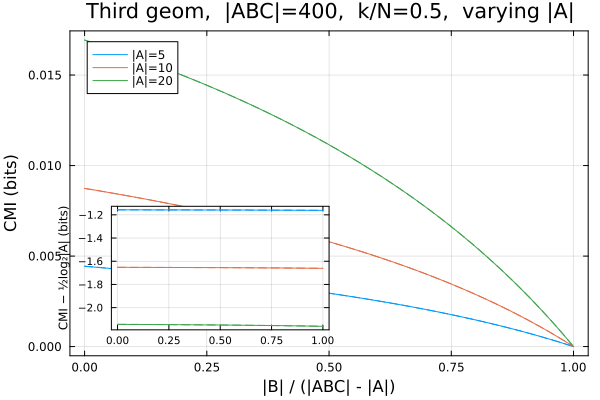

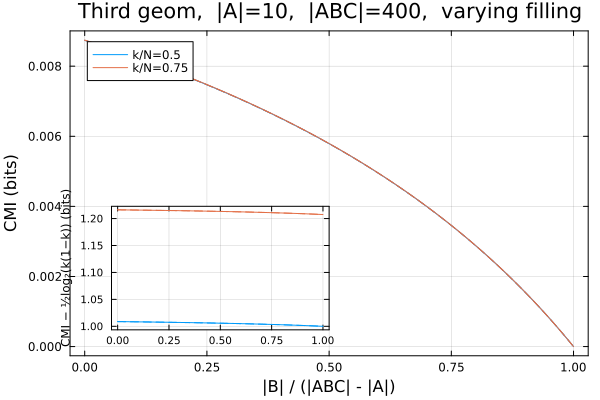

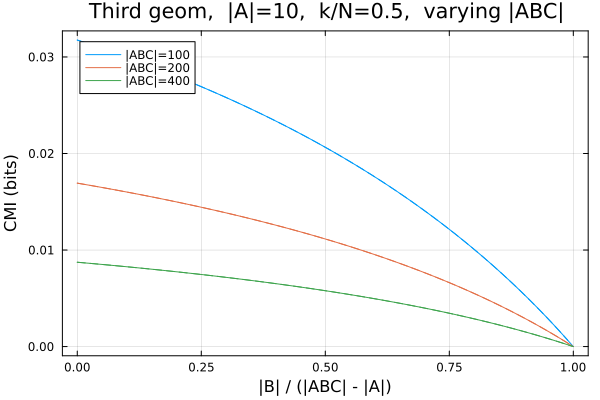

In [20]:
using Plots
using JLD2

data = load("cmi_data.jld2", "data")

const LN2 = log(2)

# ─────────────────────────────────────────────────────────────
# P6: ABC=400, filling=0.5, curves by |A|
#     inset: shift each curve by ½log₂|A| to collapse
# ─────────────────────────────────────────────────────────────

let geom = :third, ABC = 400, filling = 0.5, A_vals = [5, 10, 20]

    plt = plot()

    for (i, A) in enumerate(A_vals)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d  = data[key]
        xs = d.bs ./ (ABC - A)
        plot!(plt, xs, d.cmis ./ LN2; label = "|A|=$A", color = i)
        plot!(plt, xs, d.ana_cmis ./ LN2; color = i, linestyle = :dash, label = "")
    end
    plot!(plt;
        xlabel = "|B| / (|ABC| - |A|)",
        ylabel = "CMI (bits)",
        title  = "Third geom,  |ABC|=$ABC,  k/N=$filling,  varying |A|",
        legend = :topleft, frame = :box,
    )

    BB = bbox(0.08, 0.08, 0.42, 0.38, :bottom, :left)
    plot!(plt; inset=(1, BB), subplot=2, frame=:box, legend=false,
        ylabel="CMI − ½log₂|A| (bits)", tickfontsize=7, guidefontsize=8)
    for (i, A) in enumerate(A_vals)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d    = data[key]
        xs   = d.bs ./ (ABC - A)
        ys   = (d.cmis ./ LN2)     .- log2(A)/2
        ys_a = (d.ana_cmis ./ LN2) .- log2(A)/2
        plot!(plt, xs, ys;   subplot=2, color=i, label=false)
        plot!(plt, xs, ys_a; subplot=2, color=i, linestyle=:dash, label=false)
    end

    savefig(plt, "p6_third_vary_A.png")
    display(plt)
end

# ─────────────────────────────────────────────────────────────
# P7: A=10, ABC=400, curves by filling
#     inset: shift each curve by ½log₂(k(1-k)) to collapse.
#     Note: the :third analytic formula is filling-independent,
#     so curves should already nearly coincide; the inset
#     makes any residual filling dependence visible.
# ─────────────────────────────────────────────────────────────

let geom = :third, ABC = 400, A = 10, fillings = [0.5, 0.75]

    plt = plot()

    for (i, filling) in enumerate(fillings)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d  = data[key]
        xs = d.bs ./ (ABC - A)
        plot!(plt, xs, d.cmis ./ LN2; label = "k/N=$filling", color = i)
        plot!(plt, xs, d.ana_cmis ./ LN2; color = i, linestyle = :dash, label = "")
    end
    plot!(plt;
        xlabel = "|B| / (|ABC| - |A|)",
        ylabel = "CMI (bits)",
        title  = "Third geom,  |A|=$A,  |ABC|=$ABC,  varying filling",
        legend = :topleft, frame = :box,
    )

    BB = bbox(0.08, 0.08, 0.42, 0.38, :bottom, :left)
    plot!(plt; inset=(1, BB), subplot=2, frame=:box, legend=false,
        ylabel="CMI − ½log₂(k(1−k)) (bits)", tickfontsize=7, guidefontsize=8)
    for (i, filling) in enumerate(fillings)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d    = data[key]
        xs   = d.bs ./ (ABC - A)
        shift = log2(filling * (1 - filling)) / 2
        ys   = (d.cmis ./ LN2)     .- shift
        ys_a = (d.ana_cmis ./ LN2) .- shift
        plot!(plt, xs, ys;   subplot=2, color=i, label=false)
        plot!(plt, xs, ys_a; subplot=2, color=i, linestyle=:dash, label=false)
    end

    savefig(plt, "p7_third_vary_filling.png")
    display(plt)
end

# ─────────────────────────────────────────────────────────────
# P8: A=10, filling=0.5, curves by |ABC|
#     no inset
# ─────────────────────────────────────────────────────────────

let geom = :third, A = 10, filling = 0.5, ABC_vals = [100, 200, 400]

    plt = plot()

    for (i, ABC) in enumerate(ABC_vals)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d  = data[key]
        xs = d.bs ./ (ABC - A)
        plot!(plt, xs, d.cmis ./ LN2; label = "|ABC|=$ABC", color = i)
        plot!(plt, xs, d.ana_cmis ./ LN2; color = i, linestyle = :dash, label = "")
    end
    plot!(plt;
        xlabel = "|B| / (|ABC| - |A|)",
        ylabel = "CMI (bits)",
        title  = "Third geom,  |A|=$A,  k/N=$filling,  varying |ABC|",
        legend = :topleft, frame = :box,
    )

    savefig(plt, "p8_third_vary_ABC.png")
    display(plt)
end

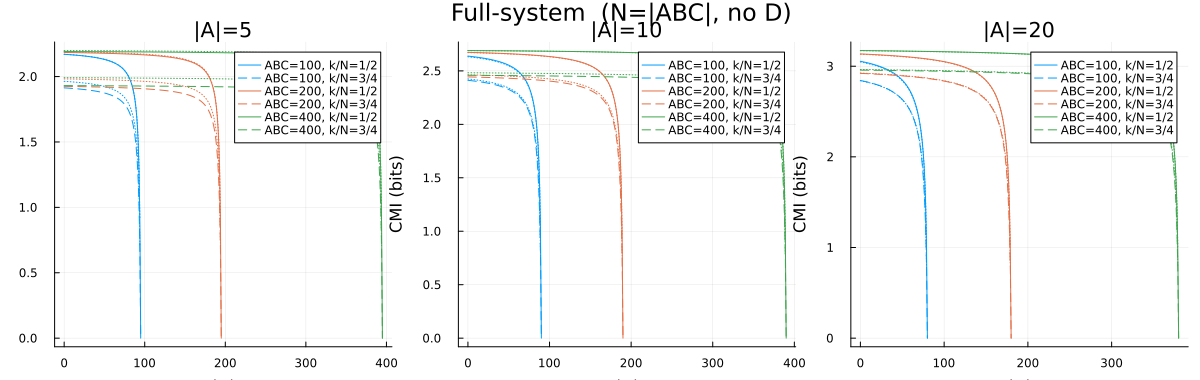

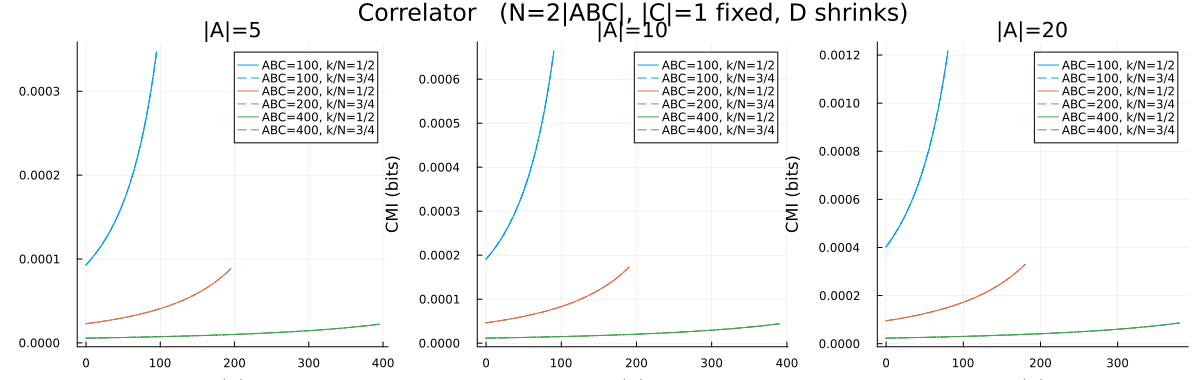

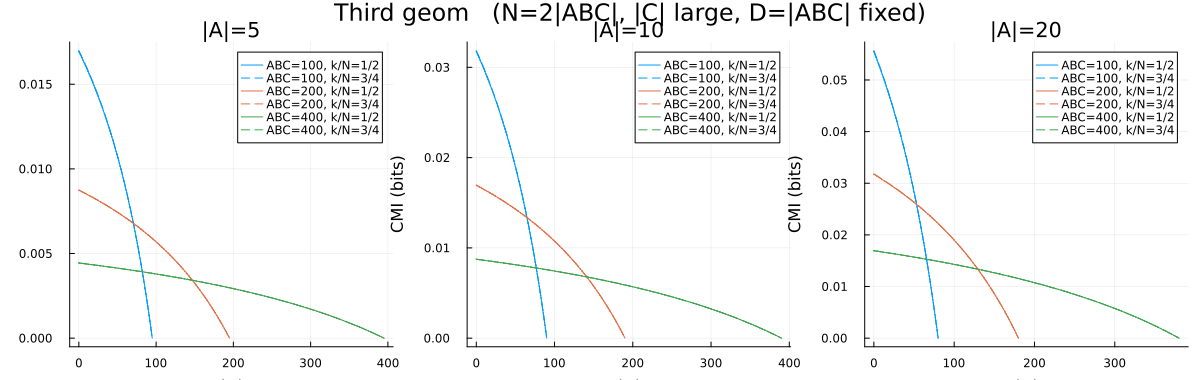

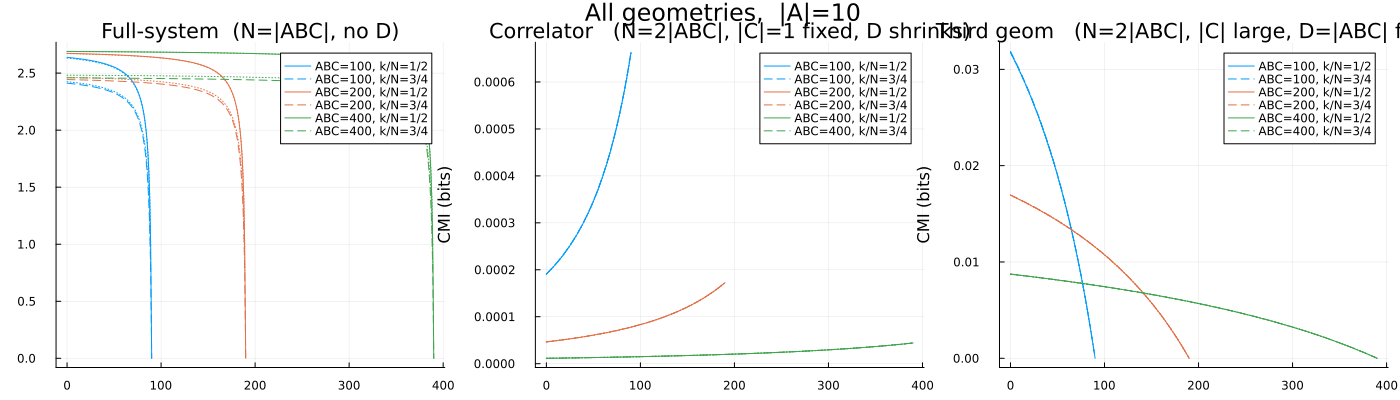

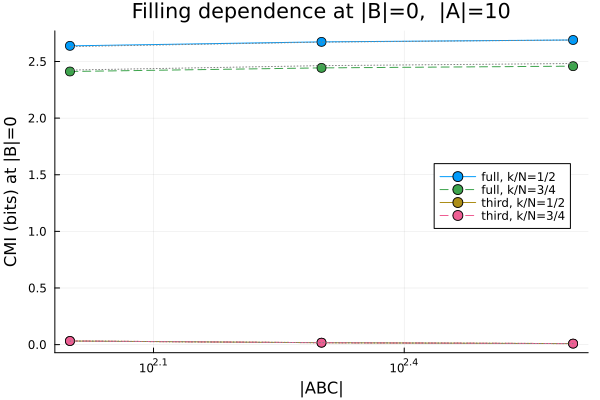

All plots saved.


In [10]:
"""
plot_cmi.jl

Load pre-computed CMI data and produce plots.
Run generate_data.jl first to produce cmi_data.jld2.

Usage:
    julia generate_data.jl        # once (slow)
    julia plot_cmi.jl             # fast; edit freely

Geometry reminder:
  :full   N=ABC,   C=ABC-A-B (shrinks),  no D
  :corr   N=2*ABC, C=1 (fixed),          D=N-A-B-1 (shrinks)
  :third  N=2*ABC, C=ABC-A-B (shrinks),  D=ABC (fixed)
"""

using Plots
using LaTeXStrings
using JLD2

# ── Load data ────────────────────────────────────────────────
# To reload a saved file instead of regenerating:
#   data = load("cmi_data.jld2", "data")

data = load("cmi_data.jld2", "data")

# ─────────────────────────────────────────────────────────────
# Shared style constants
# ─────────────────────────────────────────────────────────────

const LN2 = log(2)

# Colour by ABC value, linestyle by filling
abc_colors  = Dict(100 => 1, 200 => 2, 400 => 3)
fill_styles = Dict(0.5 => :solid, 0.75 => :dash)
fill_labels = Dict(0.5 => "k/N=1/2", 0.75 => "k/N=3/4")

geom_titles = Dict(
    :full  => "Full-system  (N=|ABC|, no D)",
    :corr  => "Correlator   (N=2|ABC|, |C|=1 fixed, D shrinks)",
    :third => "Third geom   (N=2|ABC|, |C| large, D=|ABC| fixed)",
)

# ─────────────────────────────────────────────────────────────
# Helper: one panel of CMI vs |B| for a given (geom, A)
# ─────────────────────────────────────────────────────────────

function panel_vs_B(geom::Symbol, A::Int; x_normalize=false)
    plt = plot(;
        xlabel  = x_normalize ? "|B| / (|ABC|-|A|)" : "|B|",
        ylabel  = "CMI (bits)",
        title   = "|A|=$A",
        legend  = :topright,
    )
    for ABC in [100, 200, 400], filling in [0.5, 0.75]
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d   = data[key]
        xs  = x_normalize ? d.bs ./ max(1, ABC - A) : d.bs

        any(isfinite, d.cmis) || continue
        col = abc_colors[ABC]
        sty = fill_styles[filling]

        plot!(plt, xs, d.cmis ./ LN2;
            color=col, linestyle=sty,
            label="ABC=$ABC, $(fill_labels[filling])")
        plot!(plt, xs, d.ana_cmis ./ LN2;
            color=col, linestyle=:dot, label="")
    end
    return plt
end

# ─────────────────────────────────────────────────────────────
# Plot 1: full-system CMI vs |B|, one panel per |A|
#   C shrinks as B grows; CMI should be ~flat (B-independent).
#   Dotted lines = analytic ½log(2πe k(1-k) |A||C|/(|A|+|C|)).
# ─────────────────────────────────────────────────────────────

let geom = :full
    plts = [panel_vs_B(geom, A) for A in [5, 10, 20]]
    p = plot(plts...; layout=(1,3), size=(1200, 380),
             plot_title=geom_titles[geom])
    savefig(p, "p1_full_vs_B.png")
    display(p)
end

# ─────────────────────────────────────────────────────────────
# Plot 2: correlator CMI vs |B|, one panel per |A|
#   C=1 fixed; D = N-A-B-1 shrinks → CMI increases with B.
#   Dotted lines = analytic ½log((A+D)(1+D)/(D(A+1+D))).
# ─────────────────────────────────────────────────────────────

let geom = :corr
    plts = [panel_vs_B(geom, A) for A in [5, 10, 20]]
    p = plot(plts...; layout=(1,3), size=(1200, 380),
             plot_title=geom_titles[geom])
    savefig(p, "p2_corr_vs_B.png")
    display(p)
end

# ─────────────────────────────────────────────────────────────
# Plot 3: third-geometry CMI vs |B|, one panel per |A|
#   C=ABC-A-B (large, shrinks) and D=ABC (fixed).
#   CMI decreases as B grows (C shrinks and D stays large).
#   Dotted lines = analytic ½log((A+D)(C+D)/(D(A+C+D))).
# ─────────────────────────────────────────────────────────────

let geom = :third
    plts = [panel_vs_B(geom, A) for A in [5, 10, 20]]
    p = plot(plts...; layout=(1,3), size=(1200, 380),
             plot_title=geom_titles[geom])
    savefig(p, "p3_third_vs_B.png")
    display(p)
end

# ─────────────────────────────────────────────────────────────
# Plot 4: all three geometries side-by-side at fixed |A|=10
#   Direct comparison of how D affects the CMI profile.
# ─────────────────────────────────────────────────────────────

let A = 10
    plts = [panel_vs_B(geom, A) for geom in [:full, :corr, :third]]
    for (plt, geom) in zip(plts, [:full, :corr, :third])
        title!(plt, geom_titles[geom])
    end
    p = plot(plts...; layout=(1,3), size=(1400, 400),
             plot_title="All geometries,  |A|=$A")
    savefig(p, "p4_all_geoms_A$(A).png")
    display(p)
end

# ─────────────────────────────────────────────────────────────
# Plot 5: filling dependence
#   Full-system: CMI shifts with filling (depends on k(1-k)).
#   Third geom:  CMI is filling-independent (analytic predicts flat).
#   Both at B=0 (first entry), varying ABC.
# ─────────────────────────────────────────────────────────────

let b_idx = 1   # B=0
    plt = plot(;
        xlabel = "|ABC|",
        ylabel = "CMI (bits) at |B|=0",
        title  = "Filling dependence at |B|=0,  |A|=10",
        legend = :right,
        xscale = :log10,
    )
    A = 10
    for geom in [:full, :third]
        for filling in [0.5, 0.75]
            abcs = Int[];  vals = Float64[];  anas = Float64[]
            for ABC in [100, 200, 400]
                key = (geom, A, ABC, filling)
                haskey(data, key) || continue
                d = data[key]
                push!(abcs, ABC)
                push!(vals, d.cmis[b_idx] / LN2)
                push!(anas, d.ana_cmis[b_idx] / LN2)
            end
            geom_short = geom == :full ? "full" : "third"
            plot!(plt, abcs, vals;
                marker=:circle, markersize=5,
                linestyle=fill_styles[filling],
                label="$geom_short, $(fill_labels[filling])")
            plot!(plt, abcs, anas;
                linestyle=:dot, color=:grey, label="")
        end
    end
    savefig(plt, "p5_filling.png")
    display(plt)
end

println("All plots saved.")

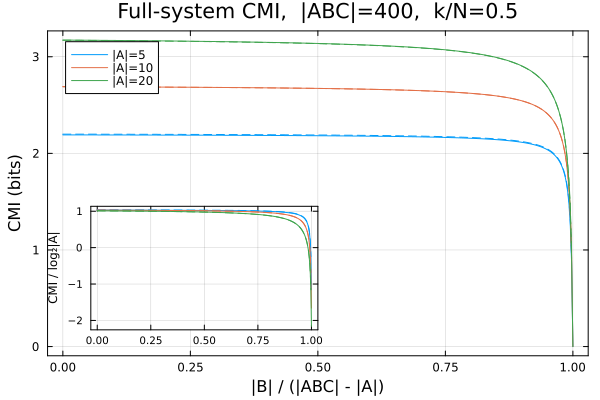

In [12]:
using Plots
using JLD2

data = load("cmi_data.jld2", "data")

let geom = :full, ABC = 400, filling = 0.5, A_vals = [5, 10, 20],
        LN2 = log(2)

    plt = plot()

    # ── main plot ────────────────────────────────────────────
    for (i, A) in enumerate(A_vals)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d  = data[key]
        xs = d.bs ./ (ABC - A)
        plot!(plt, xs, d.cmis ./ LN2; label = "|A|=$A", color = i)
        plot!(plt, xs, d.ana_cmis ./ LN2; color = i, linestyle = :dash, label = "")
    end
    plot!(plt;
        xlabel = "|B| / (|ABC| - |A|)",
        ylabel = "CMI (bits)",
        title  = "Full-system CMI,  |ABC|=$ABC,  k/N=$filling",
        legend = :topleft,
        frame  = :box,
    )

    # ── inset: initialise subplot, then add data ─────────────
    BB = bbox(0.08, 0.08, 0.42, 0.38, :bottom, :left)
    plot!(plt;
        inset   = (1, BB),
        subplot = 2,
        frame   = :box,
        legend  = false,
        xlabel  = "",
        ylabel  = "CMI / log₂|A|",
        tickfontsize  = 7,
        guidefontsize = 8,
    )
    for (i, A) in enumerate(A_vals)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d    = data[key]
        xs   = d.bs ./ (ABC - A)
        ys   = (d.cmis ./ LN2) .- log2(A)/2
        ys_a = (d.ana_cmis ./ LN2) .- log2(A)/2
        plot!(plt, xs, ys;   subplot = 2, color = i, label = false)
        plot!(plt, xs, ys_a; subplot = 2, color = i, linestyle = :dash, label = false)
    end

    savefig(plt, "p6_full_normalized.png")
    display(plt)
end

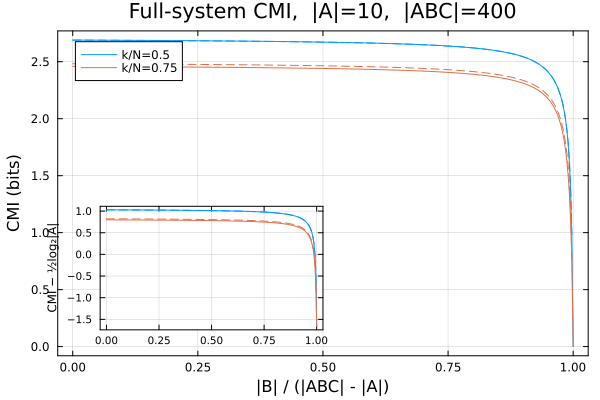

In [13]:
using Plots
using JLD2

data = load("cmi_data.jld2", "data")

# A=10, ABC=400, both fillings
let geom = :full, ABC = 400, A = 10, fillings = [0.5, 0.75], LN2 = log(2)

    plt = plot()

    # ── main plot ────────────────────────────────────────────
    for (i, filling) in enumerate(fillings)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d  = data[key]
        xs = d.bs ./ (ABC - A)
        plot!(plt, xs, d.cmis ./ LN2; label = "k/N=$filling", color = i)
        plot!(plt, xs, d.ana_cmis ./ LN2; color = i, linestyle = :dash, label = "")
    end
    plot!(plt;
        xlabel = "|B| / (|ABC| - |A|)",
        ylabel = "CMI (bits)",
        title  = "Full-system CMI,  |A|=$A,  |ABC|=$ABC",
        legend = :topleft,
        frame  = :box,
    )

    # ── inset: CMI shifted by ½log₂|A| ──────────────────────
    BB = bbox(0.08, 0.08, 0.42, 0.38, :bottom, :left)
    plot!(plt;
        inset   = (1, BB),
        subplot = 2,
        frame   = :box,
        legend  = false,
        ylabel  = "CMI − ½log₂|A|",
        tickfontsize  = 7,
        guidefontsize = 8,
    )
    for (i, filling) in enumerate(fillings)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d    = data[key]
        xs   = d.bs ./ (ABC - A)
        ys   = (d.cmis ./ LN2)     .- log2(A)/2
        ys_a = (d.ana_cmis ./ LN2) .- log2(A)/2
        plot!(plt, xs, ys;   subplot = 2, color = i, label = false)
        plot!(plt, xs, ys_a; subplot = 2, color = i, linestyle = :dash, label = false)
    end

    savefig(plt, "p7_full_fillings.png")
    display(plt)
end

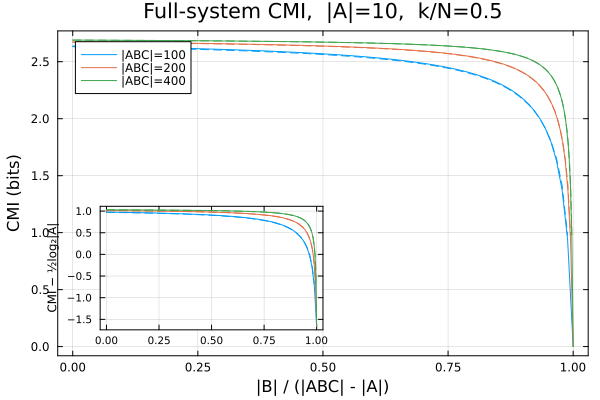

In [14]:
using Plots
using JLD2

data = load("cmi_data.jld2", "data")

# A=10, filling=0.5, all ABC sizes
let geom = :full, A = 10, filling = 0.5, ABC_vals = [100, 200, 400], LN2 = log(2)

    plt = plot()

    # ── main plot ────────────────────────────────────────────
    for (i, ABC) in enumerate(ABC_vals)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d  = data[key]
        xs = d.bs ./ (ABC - A)
        plot!(plt, xs, d.cmis ./ LN2; label = "|ABC|=$ABC", color = i)
        plot!(plt, xs, d.ana_cmis ./ LN2; color = i, linestyle = :dash, label = "")
    end
    plot!(plt;
        xlabel = "|B| / (|ABC| - |A|)",
        ylabel = "CMI (bits)",
        title  = "Full-system CMI,  |A|=$A,  k/N=$filling",
        legend = :topleft,
        frame  = :box,
    )

    # ── inset: CMI shifted by ½log₂|A| ──────────────────────
    BB = bbox(0.08, 0.08, 0.42, 0.38, :bottom, :left)
    plot!(plt;
        inset   = (1, BB),
        subplot = 2,
        frame   = :box,
        legend  = false,
        ylabel  = "CMI − ½log₂|A|",
        tickfontsize  = 7,
        guidefontsize = 8,
    )
    for (i, ABC) in enumerate(ABC_vals)
        key = (geom, A, ABC, filling)
        haskey(data, key) || continue
        d    = data[key]
        xs   = d.bs ./ (ABC - A)
        ys   = (d.cmis ./ LN2)     .- log2(A)/2
        ys_a = (d.ana_cmis ./ LN2) .- log2(A)/2
        plot!(plt, xs, ys;   subplot = 2, color = i, label = false)
        plot!(plt, xs, ys_a; subplot = 2, color = i, linestyle = :dash, label = false)
    end

    savefig(plt, "p8_full_abc_sizes.png")
    display(plt)
end